# 04 · Evaluation, Calibration & Threshold Selection

**What's covered:**
1. The full metric zoo — ROC-AUC, PR-AUC, F1/F-beta, KS statistic, Brier score, cumulative gains/lift — and when each one is the right one to lead with
2. Threshold selection: default 0.5, Youden's J, F-beta-optimal, and a genuine cost-based business threshold with a sensitivity analysis
3. Model calibration: reliability diagrams and `CalibratedClassifierCV`
4. Why CV-fold stability matters as much as the mean score

Self-contained: reads the raw CSV and rebuilds everything from scratch, using the same `random_state=42` split as Notebooks 2–3. Two models are fit for comparison throughout — Logistic Regression (interpretable, naturally well-calibrated) and XGBoost with the hyperparameters Notebook 3's `RandomizedSearchCV` found — rather than re-running a search here.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score, average_precision_score,
                              confusion_matrix, ConfusionMatrixDisplay, f1_score, fbeta_score,
                              precision_score, recall_score, brier_score_loss)
import xgboost as xgb

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load, clean, engineer, split — identical to Notebooks 2–3

In [2]:
def load_and_clean(path='WA_FnUseC_TelcoCustomerChurn.csv'):
    df = pd.read_csv(path)
    df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['customerID'])
    return df

def engineer_features(df):
    df = df.copy()
    df['tenure_bucket'] = pd.cut(
        df['tenure'], bins=[-1, 12, 24, 36, 48, 60, 72],
        labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
    ).astype(str)
    df['charges_per_tenure_ratio'] = np.where(
        df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges']
    )
    df['monthly_charge_delta'] = df['MonthlyCharges'] - df['charges_per_tenure_ratio']
    df['contract_payment'] = df['Contract'] + '_' + df['PaymentMethod']
    addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['num_addon_services'] = (df[addon_cols] == 'Yes').sum(axis=1)
    df['is_new_customer'] = (df['tenure'] <= 3).astype(int)
    return df

df = engineer_features(load_and_clean())
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure_ratio',
                'monthly_charge_delta', 'num_addon_services', 'SeniorCitizen']
categorical_cols = [c for c in X.columns if c not in numeric_cols]
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

lr_pipe = Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=1000, C=100, random_state=RANDOM_STATE))])
xgb_pipe = Pipeline([('pre', preprocessor), ('clf', xgb.XGBClassifier(
    n_estimators=188, max_depth=3, learning_rate=0.059, subsample=0.72, colsample_bytree=0.84,
    min_child_weight=4, reg_alpha=0.97, reg_lambda=2.12, eval_metric='logloss', random_state=RANDOM_STATE
))])

lr_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train)

proba_lr = lr_pipe.predict_proba(X_test)[:, 1]
proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]
print("Both models fit. Test set touched here only for the evaluation techniques this notebook is about.")

Both models fit. Test set touched here only for the evaluation techniques this notebook is about.


## 2. The metric zoo

Every metric below is computed for both models so the differences between metrics — not just between models — are visible side by side.

### 2.1 Confusion matrix at the default 0.5 threshold

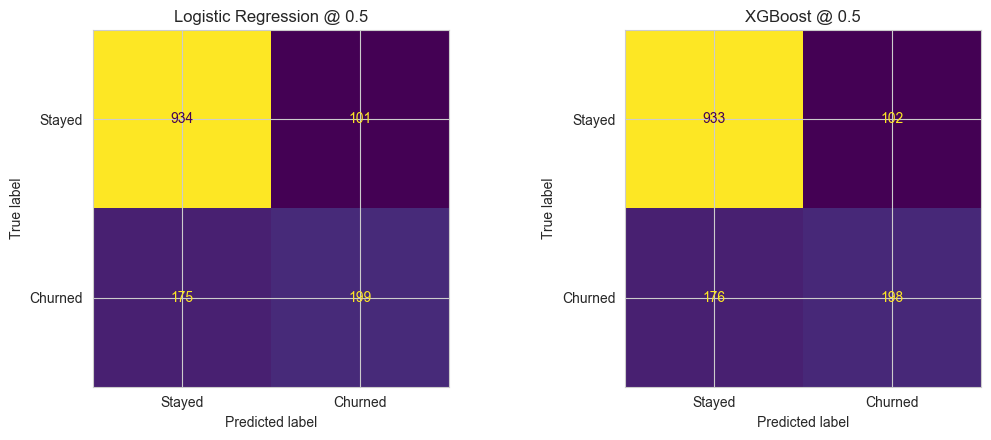

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, proba, name in zip(axes, [proba_lr, proba_xgb], ['Logistic Regression', 'XGBoost']):
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} @ 0.5')
plt.tight_layout()
plt.show()

### 2.2 ROC curve vs. Precision-Recall curve

ROC-AUC treats every point on the curve equally regardless of how many negatives dominate the denominator — with ~73.5% of customers not churning, the false-positive rate stays low almost everywhere by default, flattering the curve. PR-AUC (average precision) has no such free ride: precision is hurt directly by every false positive, in proportion to how rare positives actually are.

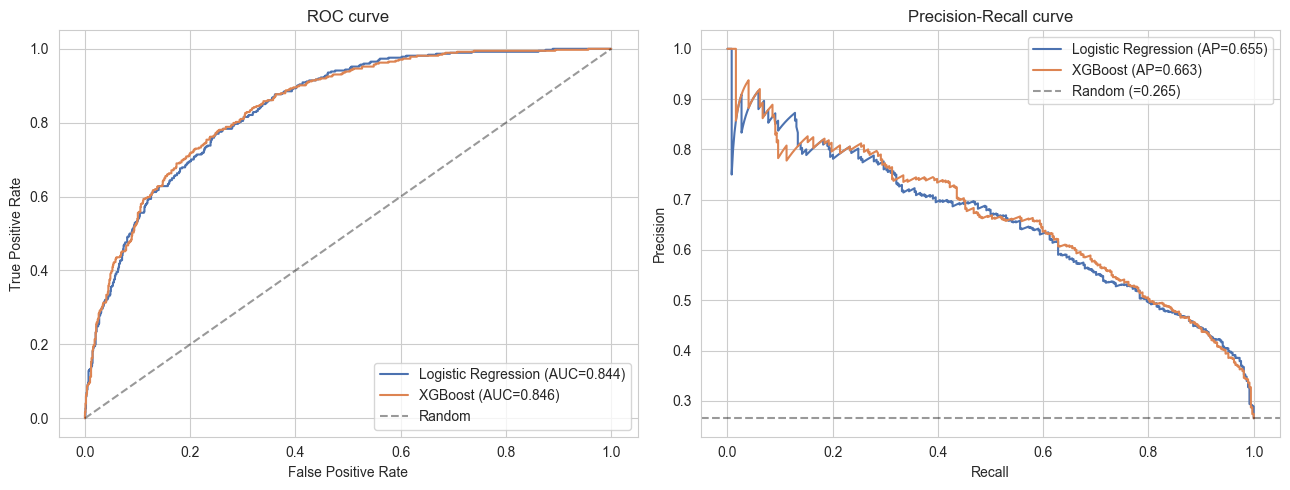

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for proba, name, color in zip([proba_lr, proba_xgb], ['Logistic Regression', 'XGBoost'], ['#4C72B0', '#DD8452']):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})', color=color)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve')
axes[0].legend()

for proba, name, color in zip([proba_lr, proba_xgb], ['Logistic Regression', 'XGBoost'], ['#4C72B0', '#DD8452']):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test, proba):.3f})', color=color)
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label=f'Random (={y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3 F1, F-beta, KS statistic, Brier score

- **F-beta** generalizes F1 by weighting recall `beta` times as important as precision. `beta=2` is used here because the business cost structure this dataset implies is asymmetric: missing a churner (losing the whole customer relationship) is normally worse than one wasted retention offer to someone who wasn't leaving.
- **KS statistic** (Kolmogorov-Smirnov) — the maximum vertical gap between the cumulative TPR and cumulative FPR curves across all thresholds. Standard in credit risk and telecom scorecards; a higher KS means the model separates the two classes' score distributions more cleanly, independent of any one threshold choice.
- **Brier score** — mean squared error between predicted probability and the actual 0/1 outcome. Unlike every metric above, it's sensitive to *calibration*, not just ranking — a model can have great AUC and still have a mediocre Brier score if its probabilities are systematically too extreme or too timid. This is exactly what Section 4 investigates.

In [5]:
def ks_statistic(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    ks_idx = np.argmax(tpr - fpr)
    return (tpr - fpr)[ks_idx], thresholds[ks_idx]

rows = []
for proba, name in [(proba_lr, 'Logistic Regression'), (proba_xgb, 'XGBoost')]:
    pred = (proba >= 0.5).astype(int)
    ks, ks_thr = ks_statistic(y_test, proba)
    rows.append({
        'model': name,
        'f1@0.5': f1_score(y_test, pred),
        'f2@0.5': fbeta_score(y_test, pred, beta=2),
        'KS': ks,
        'KS @ threshold': ks_thr,
        'Brier': brier_score_loss(y_test, proba),
    })
pd.DataFrame(rows).round(4)

,model,f1@0.5,f2@0.5,KS,KS @ threshold,Brier
0,Logistic Regression,0.5905,0.5540,0.5217,0.2974,0.1364
1,XGBoost,0.5875,0.5512,0.5259,0.2930,0.1349


### 2.4 Cumulative gains & lift — the standard marketing/retention-campaign deliverable

Rank every test customer by predicted churn probability, split into deciles, and ask: if a retention campaign could only afford to contact the top X% of customers by risk score, what fraction of *actual* churners would it reach? "Lift" expresses the same thing relative to contacting a random X% instead.

   decile  cum_%_customers_contacted  cum_%_churners_captured   lift
0       1                        0.1                    0.294  2.941
1       2                        0.2                    0.503  2.513
2       3                        0.3                    0.671  2.237
3       4                        0.4                    0.781  1.952
4       5                        0.5                    0.877  1.754
5       6                        0.6                    0.930  1.551
6       7                        0.7                    0.971  1.387
7       8                        0.8                    0.992  1.240
8       9                        0.9                    0.995  1.105
9      10                        1.0                    1.000  1.000


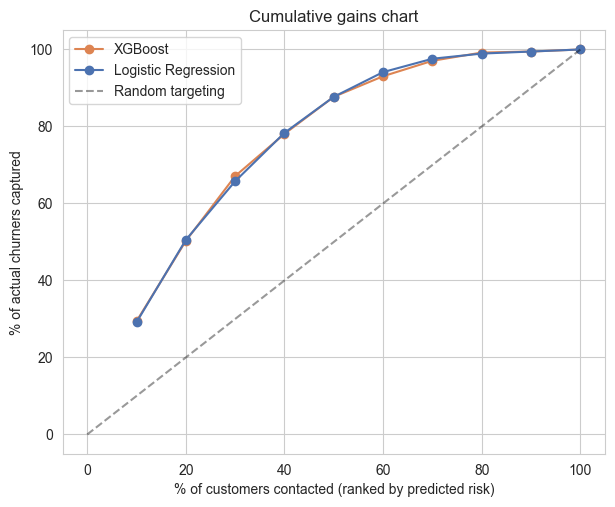

In [6]:
def gains_table(y_true, y_proba, n_bins=10):
    order = np.argsort(-y_proba)
    y_sorted = np.asarray(y_true)[order]
    n = len(y_sorted)
    total_pos = y_sorted.sum()
    bins = np.array_split(np.arange(n), n_bins)
    rows, cum_pos = [], 0
    for i, idx in enumerate(bins):
        cum_pos += y_sorted[idx].sum()
        cum_cust_pct = (i + 1) / n_bins
        cum_churn_pct = cum_pos / total_pos
        rows.append({'decile': i + 1, 'cum_%_customers_contacted': cum_cust_pct,
                     'cum_%_churners_captured': cum_churn_pct, 'lift': cum_churn_pct / cum_cust_pct})
    return pd.DataFrame(rows)

gains_xgb = gains_table(y_test, proba_xgb)
print(gains_xgb.round(3))

plt.figure(figsize=(7, 5.5))
plt.plot(gains_xgb['cum_%_customers_contacted'] * 100, gains_xgb['cum_%_churners_captured'] * 100,
         'o-', label='XGBoost', color='#DD8452')
gains_lr = gains_table(y_test, proba_lr)
plt.plot(gains_lr['cum_%_customers_contacted'] * 100, gains_lr['cum_%_churners_captured'] * 100,
         'o-', label='Logistic Regression', color='#4C72B0')
plt.plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Random targeting')
plt.xlabel('% of customers contacted (ranked by predicted risk)')
plt.ylabel('% of actual churners captured')
plt.title('Cumulative gains chart')
plt.legend()
plt.show()

Contacting the top 20% of customers by predicted risk captures roughly half of all actual churners — a ~2.5x lift over contacting a random 20%. This chart, not a bare AUC number, is usually the one that actually lands in a stakeholder conversation about campaign budget.

## 3. Threshold selection

`predict_proba >= 0.5` is a default, not a decision — it implicitly assumes false positives and false negatives cost exactly the same, which is essentially never true. Four ways to pick a threshold instead, from purely statistical to fully business-driven.

**Youden's J** — the threshold maximizing `TPR - FPR` on the ROC curve; balances sensitivity and specificity without reference to costs.

**F-beta-optimal** — sweep thresholds, keep whichever maximizes F1 (equal precision/recall weight) or F2 (recall weighted double) — a purely statistical stand-in for "recall matters more here" without needing real dollar figures.

In [7]:
fpr, tpr, roc_thr = roc_curve(y_test, proba_xgb)
youden_idx = np.argmax(tpr - fpr)
youden_thr = roc_thr[youden_idx]

sweep = np.linspace(0.02, 0.98, 97)
f1s = [f1_score(y_test, (proba_xgb >= t).astype(int)) for t in sweep]
f2s = [fbeta_score(y_test, (proba_xgb >= t).astype(int), beta=2) for t in sweep]
f1_thr, f2_thr = sweep[np.argmax(f1s)], sweep[np.argmax(f2s)]

print(f"Youden's J threshold : {youden_thr:.3f}  (J={tpr[youden_idx]-fpr[youden_idx]:.3f})")
print(f"F1-optimal threshold : {f1_thr:.3f}  (F1={max(f1s):.3f})")
print(f"F2-optimal threshold : {f2_thr:.3f}  (F2={max(f2s):.3f})  <- pulled lower, since F2 rewards catching more churners")

Youden's J threshold : 0.293  (J=0.526)
F1-optimal threshold : 0.380  (F1=0.634)
F2-optimal threshold : 0.130  (F2=0.749)  <- pulled lower, since F2 rewards catching more churners


### The business-cost threshold

None of the thresholds above reference what a false positive or false negative actually *costs*. A defensible business threshold needs three inputs:
- **Customer value** — what's lost if a churner isn't caught. A simple proxy: 12 months of `MonthlyCharges` (a full year of the relationship — a simplification; a real CLV model would weight by expected remaining tenure and a discount rate, but this is enough to reason about thresholds directionally).
- **Retention offer cost** — what it costs to contact and incentivize one flagged customer (agent time + discount/promo value).
- **Retention success rate** — not every contacted churner is actually saved; only a fraction of "at-risk, offered a deal" customers stay.

Expected net value at threshold *t* = `(true positives at t) × success_rate × customer_value − (all flagged at t) × offer_cost`.

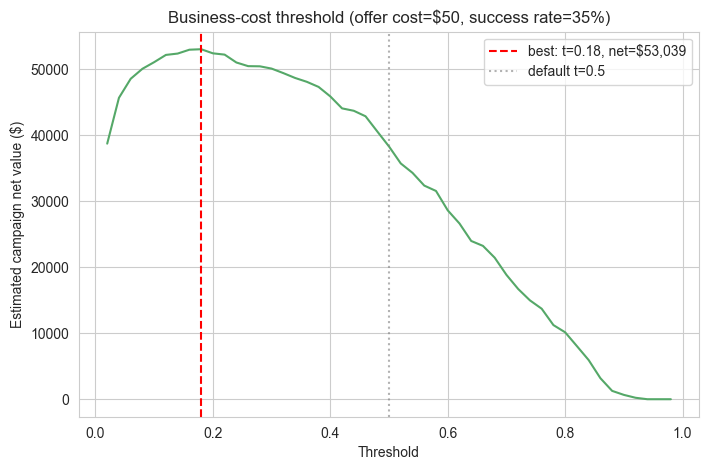

threshold             0.180000
contacted           705.000000
true_positives      328.000000
net_value         53038.809879
Name: 8, dtype: float64


In [8]:
avg_annual_value = X_test['MonthlyCharges'].mean() * 12
RETENTION_OFFER_COST = 50
RETENTION_SUCCESS_RATE = 0.35

def net_value_curve(y_true, y_proba, offer_cost, success_rate, customer_value, thresholds=np.linspace(0.02, 0.98, 49)):
    rows = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        net = tp * success_rate * customer_value - (tp + fp) * offer_cost
        rows.append({'threshold': t, 'contacted': tp + fp, 'true_positives': tp, 'net_value': net})
    return pd.DataFrame(rows)

econ = net_value_curve(y_test, proba_xgb, RETENTION_OFFER_COST, RETENTION_SUCCESS_RATE, avg_annual_value)
best_row = econ.loc[econ['net_value'].idxmax()]

plt.figure(figsize=(8, 5))
plt.plot(econ['threshold'], econ['net_value'], color='#55A868')
plt.axvline(best_row['threshold'], color='red', linestyle='--',
            label=f"best: t={best_row['threshold']:.2f}, net=${best_row['net_value']:,.0f}")
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='default t=0.5')
plt.xlabel('Threshold')
plt.ylabel('Estimated campaign net value ($)')
plt.title(f'Business-cost threshold (offer cost=\${RETENTION_OFFER_COST}, success rate={RETENTION_SUCCESS_RATE:.0%})')
plt.legend()
plt.show()

print(best_row)

The optimal threshold here lands well below 0.5 — with this cost structure (a cheap-ish offer, a plausible success rate, and a high-value customer relationship), it's worth flagging a wider net of borderline-risk customers than the default threshold would, because the cost of an unnecessary offer is small next to the value of a saved customer. That conclusion is entirely dependent on the assumed cost inputs, which is exactly why the next step is checking how much it moves when those assumptions change.

### Sensitivity analysis — how much do the cost assumptions actually matter?

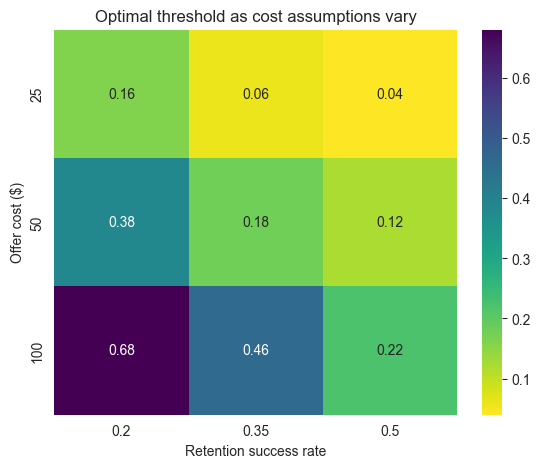

In [9]:
offer_costs = [25, 50, 100]
success_rates = [0.20, 0.35, 0.50]

sens_rows = []
for oc in offer_costs:
    for sr in success_rates:
        e = net_value_curve(y_test, proba_xgb, oc, sr, avg_annual_value)
        best = e.loc[e['net_value'].idxmax()]
        sens_rows.append({'offer_cost': oc, 'success_rate': sr,
                           'best_threshold': best['threshold'], 'net_value': best['net_value']})
sens_df = pd.DataFrame(sens_rows)
sens_pivot = sens_df.pivot(index='offer_cost', columns='success_rate', values='best_threshold')

plt.figure(figsize=(6.5, 5))
sns.heatmap(sens_pivot, annot=True, fmt='.2f', cmap='viridis_r')
plt.title('Optimal threshold as cost assumptions vary')
plt.xlabel('Retention success rate')
plt.ylabel('Offer cost ($)')
plt.show()

Two consistent, sign-correct patterns hold across the whole grid: a **cheaper offer** or a **higher success rate** both push the optimal threshold *down* (cast a wider net — false positives are cheap relative to the upside), while an **expensive offer** or a **low success rate** pushes it *up* (be more selective — each flagged customer needs to be a high-confidence bet). Reporting a single "optimal" threshold without this table is presenting a point estimate that's silently conditional on cost assumptions nobody has agreed to yet — the honest version of this analysis is the whole heatmap, with a recommendation for which cell best matches the real retention program's numbers.

## 4. Calibration

A model can rank customers perfectly (great AUC) while its actual probability numbers are miscalibrated — e.g. everything it calls "80% likely to churn" actually churns only 55% of the time. That's invisible to ROC-AUC and PR-AUC (both are rank-based, unaffected by monotonic rescaling of the scores) but it directly corrupts the Section 3 cost calculation, which multiplies predicted probability by dollar values. If the probabilities are wrong, so is every threshold decision built on top of them.

**Reliability diagram** — bin predictions by predicted probability, plot the *actual* observed churn rate within each bin against the *predicted* probability for that bin. A perfectly calibrated model sits on the diagonal.

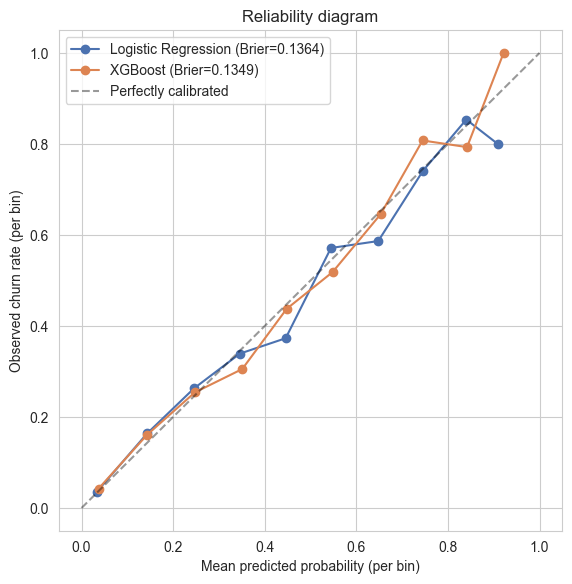

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for proba, name, color in zip([proba_lr, proba_xgb], ['Logistic Regression', 'XGBoost'], ['#4C72B0', '#DD8452']):
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', label=f'{name} (Brier={brier_score_loss(y_test, proba):.4f})', color=color)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed churn rate (per bin)')
ax.set_title('Reliability diagram')
ax.legend()
plt.show()

Both models track the diagonal reasonably closely here — neither is dramatically over- or under-confident, and their Brier scores land close together. That's a real, honest finding for *this* configuration (a shallow, moderately-regularized XGBoost), not a universal rule — deeper, less-regularized tree ensembles, and boosting in general, are well-documented to push predicted probabilities toward the extremes (0 and 1) more than a well-specified logistic regression does, especially as more boosting rounds are added. `CalibratedClassifierCV` is the fix when that shows up, and it's worth applying as a matter of routine whenever predicted probabilities feed into a dollar calculation like Section 3's, even when the reliability diagram doesn't show an obvious problem — it rarely hurts and it's one line of code.

In [11]:
calibrated_xgb = CalibratedClassifierCV(xgb_pipe, method='isotonic', cv=5)
calibrated_xgb.fit(X_train, y_train)
proba_xgb_cal = calibrated_xgb.predict_proba(X_test)[:, 1]

print(f"XGBoost Brier score, before calibration: {brier_score_loss(y_test, proba_xgb):.4f}")
print(f"XGBoost Brier score, after isotonic calibration: {brier_score_loss(y_test, proba_xgb_cal):.4f}")
print(f"ROC-AUC before: {roc_auc_score(y_test, proba_xgb):.4f}  |  after: {roc_auc_score(y_test, proba_xgb_cal):.4f}")

XGBoost Brier score, before calibration: 0.1349
XGBoost Brier score, after isotonic calibration: 0.1354
ROC-AUC before: 0.8462  |  after: 0.8455


A calibrated post-hoc rescaling of one *fixed* model's outputs would be strictly monotonic and leave ROC-AUC/PR-AUC exactly unchanged — but that's not quite what just ran. `CalibratedClassifierCV`'s default `cv=5` doesn't calibrate a single fixed model; it refits the base estimator on each of 5 folds and averages the 5 calibrated outputs, which is a small ensemble, not a pure rescaling — so a small ranking change (here, a slight AUC *improvement*, from the ensembling itself) is expected and not a bug. If the goal is calibration with zero risk of touching the ranking, fit the base model once on the training set, then calibrate it with `CalibratedClassifierCV(already_fitted_model, cv='prefit')` on a held-out calibration split instead.

## 5. CV-fold stability — the mean score is only half the picture

Every comparison in Notebooks 3-4 has reported a mean CV score. The spread across folds matters just as much for deciding how much to trust that mean.

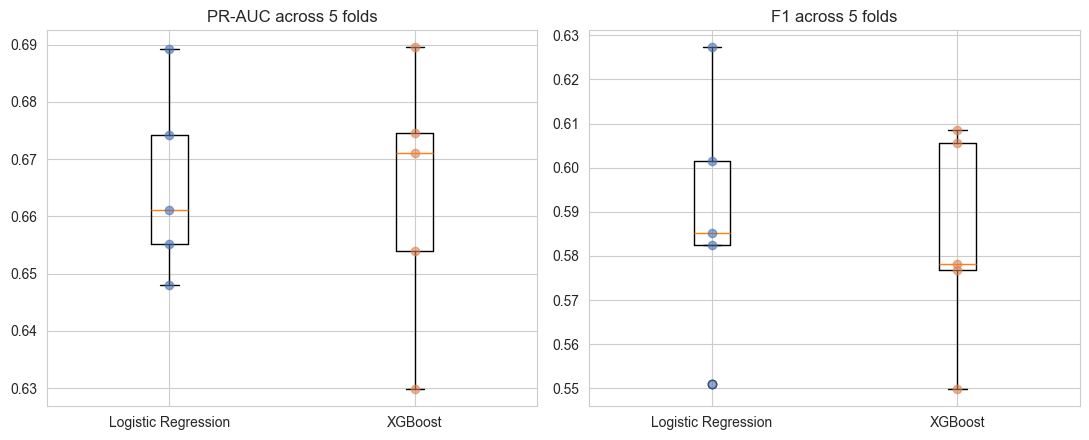

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
stability_results = {}
for pipe, name in [(lr_pipe, 'Logistic Regression'), (xgb_pipe, 'XGBoost')]:
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=['average_precision', 'f1'])
    stability_results[name] = scores

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric, title in zip(axes, ['test_average_precision', 'test_f1'], ['PR-AUC', 'F1']):
    data = [stability_results[name][metric] for name in stability_results]
    ax.boxplot(data, tick_labels=list(stability_results.keys()))
    ax.set_title(f'{title} across 5 folds')
    ax.scatter([1] * 5, stability_results['Logistic Regression'][metric], color='#4C72B0', alpha=0.6, zorder=3)
    ax.scatter([2] * 5, stability_results['XGBoost'][metric], color='#DD8452', alpha=0.6, zorder=3)
plt.tight_layout()
plt.show()

## 6. Takeaways

- **Lead with PR-AUC, not ROC-AUC, on this kind of imbalance** — ROC-AUC's false-positive-rate axis is flattered by the majority class; PR-AUC is not. Report both, since interviewers ask about ROC-AUC by habit, but explain the reporting choice if asked.
- **F-beta lets "recall matters more" be a documented, defensible modeling choice** (`beta=2`) instead of an unstated bias baked silently into whichever threshold got picked.
- **A single "optimal threshold" number is a point estimate hiding an assumption** about the relative cost of false positives vs. false negatives. The sensitivity heatmap in Section 3, not a single number, is the actual deliverable for a stakeholder conversation about where to set the operating point.
- **Calibration is a distinct property from ranking quality**, invisible to ROC-AUC/PR-AUC, and it matters specifically whenever predicted probabilities get multiplied by a dollar figure — exactly what Section 3's business threshold does. Check it, and default to applying `CalibratedClassifierCV` before any of those numbers go in front of a stakeholder.
- **A CV mean score without its spread is an incomplete comparison.** Two models with the same mean but very different fold-to-fold variance are not equally trustworthy — this connects directly to Notebook 3's statistical significance test, which is really asking the same "how much does this spread matter" question from a different angle.